In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Базовая работа с изображением

In [2]:
image = cv2.imread('sar_2_color.jpg')

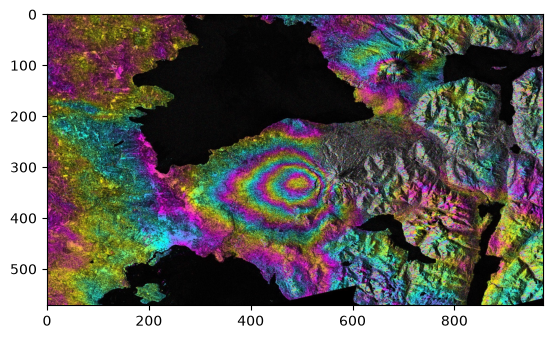

In [3]:
plt.imshow(image)

In [4]:
image.shape # h,w,c

(572, 974, 3)

In [5]:
image[250,250] # b,g,r

array([12, 12, 12], dtype=uint8)

In [6]:
# ROI
img_roi = image[100:200, 500:700]

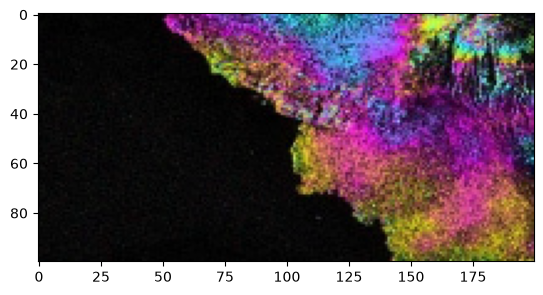

In [7]:
plt.imshow(img_roi)

In [8]:
b,g,r = cv2.split(image)

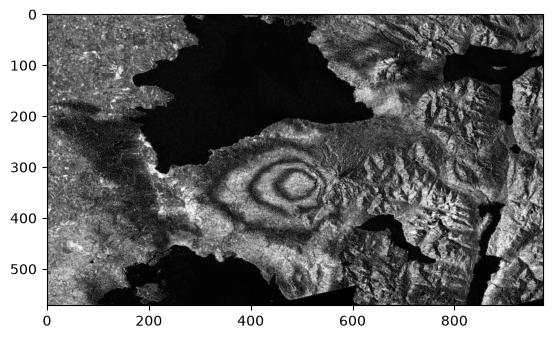

In [9]:
plt.imshow(b, cmap = 'gray')

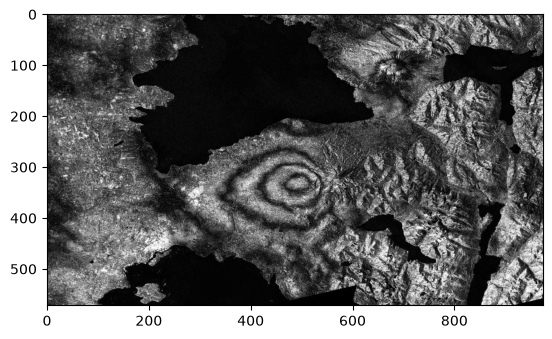

In [10]:
plt.imshow(g, cmap = 'gray')

In [11]:
# alternative approach
b = image[:,:,0]

In [12]:
import copy

image2 = copy.deepcopy(image)

In [13]:
image2[50:100,50:100] = [0,0,0]

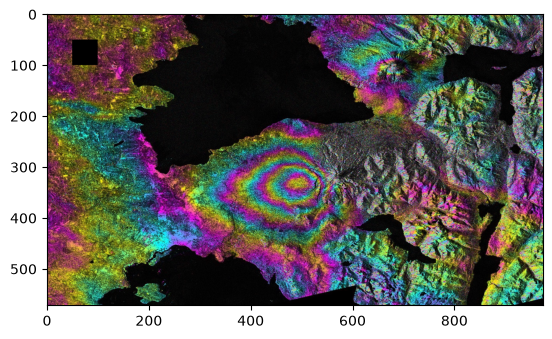

In [14]:
plt.imshow(image2)

In [15]:
# empty image
image_template = np.zeros(image.shape,np.uint8)

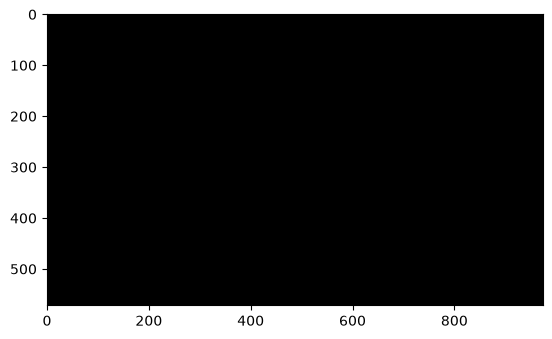

In [16]:
plt.imshow(image_template)

# Конвертация цветовых моделей

In [17]:
image_template[0,0]

array([0, 0, 0], dtype=uint8)

In [18]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

In [19]:
image_gray[0,0]

np.uint8(40)

In [20]:
image_gray.shape

(572, 974)

In [21]:
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV) 

In [22]:
image_hsv.shape

(572, 974, 3)

In [23]:
image_hsv[0,0]

array([117, 143,  75], dtype=uint8)

In [24]:
image[0,0]

array([75, 37, 33], dtype=uint8)

In [25]:
image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)

In [26]:
image_lab[0,0]

array([ 42, 139, 104], dtype=uint8)

# Пороговая фильтрация

In [27]:
_,thresh1 = cv2.threshold(image_gray,200,255,cv2.THRESH_BINARY)

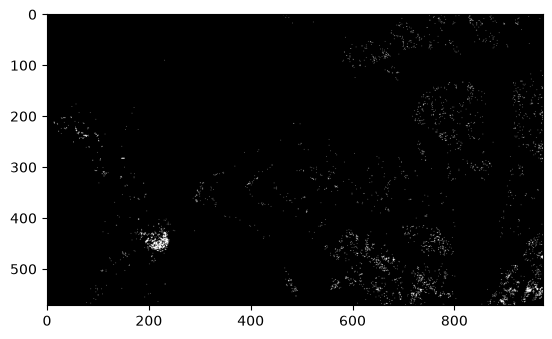

In [28]:
plt.imshow(thresh1, cmap='gray')

In [29]:
thresh1[thresh1==100].sum()

np.uint64(0)

# Построение гистограммы

In [30]:
histSize = 256
histRange = (0, 256)
accumulate = False

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)

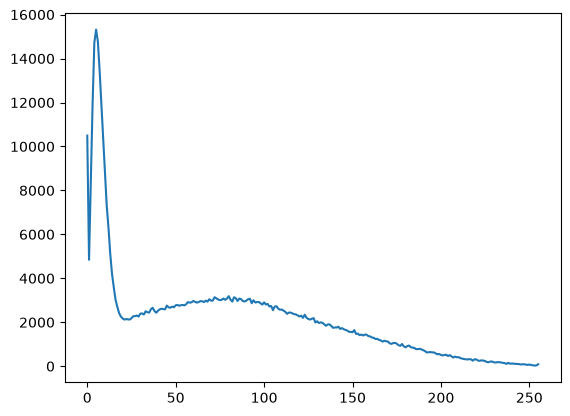

In [31]:
plt.plot(b_hist)

In [32]:
b_hist_cum = b_hist.cumsum()

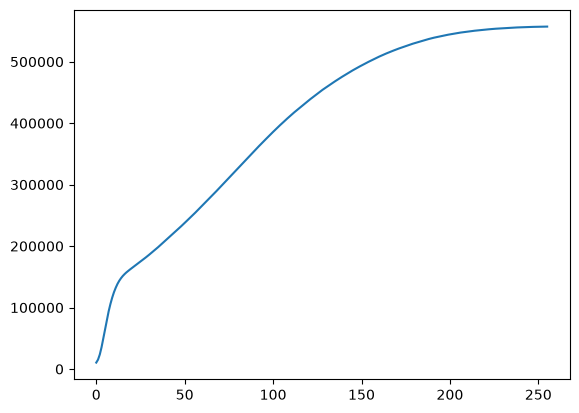

In [33]:
plt.plot(b_hist_cum)

In [34]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])

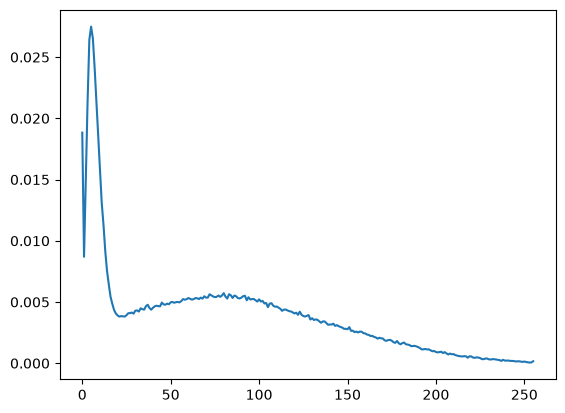

In [35]:
plt.plot(b_hist_norm)

# Сравнение двух изображений

In [36]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray, full=True)
diff = (diff * 255).astype("uint8")
print("SSIM: {}".format(ssim))

SSIM: 1.0


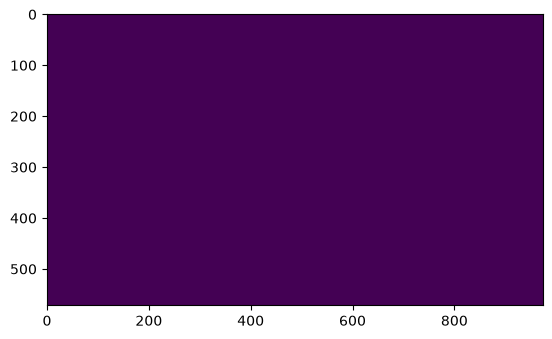

In [37]:
plt.imshow(diff)

In [38]:
mse = mean_squared_error(image_gray, image_gray)
mse

np.float64(0.0)

# Статистические характеристики изображений

In [39]:
mean = image_gray.mean()

In [40]:
std = image_gray.std()

In [41]:
print(mean,std)

67.41225535245043 52.01619187595963


In [42]:
eq_gray = cv2.equalizeHist(image_gray)

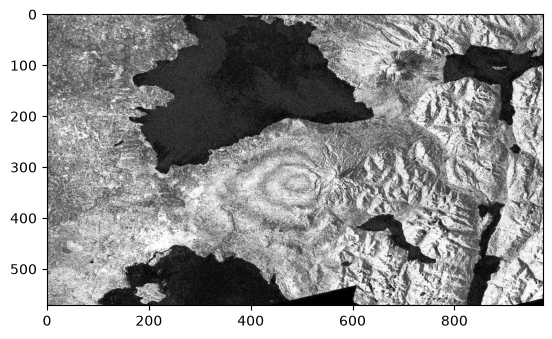

In [43]:
plt.imshow(eq_gray, cmap="gray")


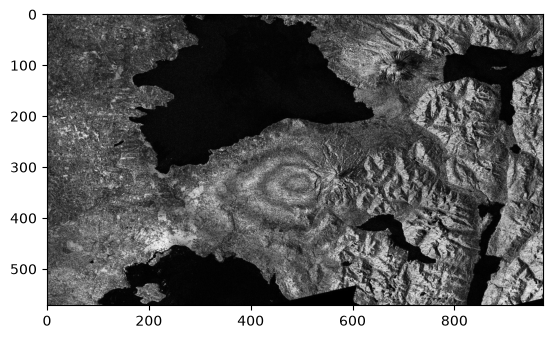

In [44]:
plt.imshow(image_gray, cmap="gray")

In [45]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


# Решение задания: `sar_1_gray.jpg`

In [46]:
from skimage.metrics import structural_similarity, mean_squared_error

## 1. Загрузка изображения в оттенках серого

shape (h, w): (400, 600)
dtype:        uint8
min / max:    0 / 255


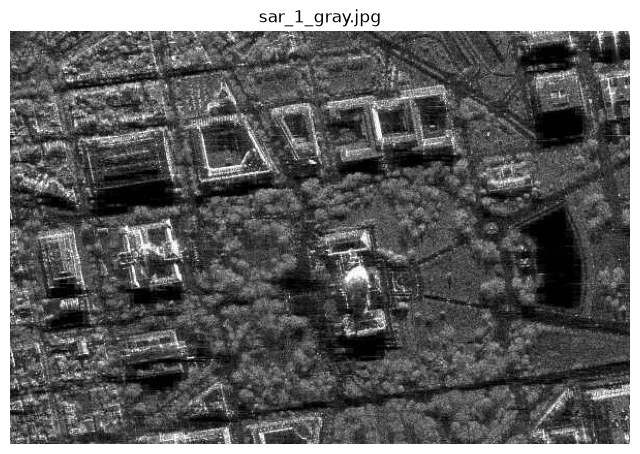

In [47]:
sar = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

print("shape (h, w):", sar.shape)
print("dtype:       ", sar.dtype)
print("min / max:   ", sar.min(), "/", sar.max())

plt.figure(figsize=(8, 6))
plt.imshow(sar, cmap='gray', vmin=0, vmax=255)
plt.title('sar_1_gray.jpg')
plt.axis('off')
plt.show()

## 2. Гистограмма
Гистограмма считается вручную (`np.bincount`) и сверяется с `cv2.calcHist`. Рядом строится кумулятивная гистограмма $H'(i)=\sum_{0\le j\le i}H(j)$ — она понадобится для эквализации.

совпадает с cv2.calcHist: True
сумма гистограммы = 240000 = h*w = 240000
самое частое значение яркости: 1 (3786 пикс.)


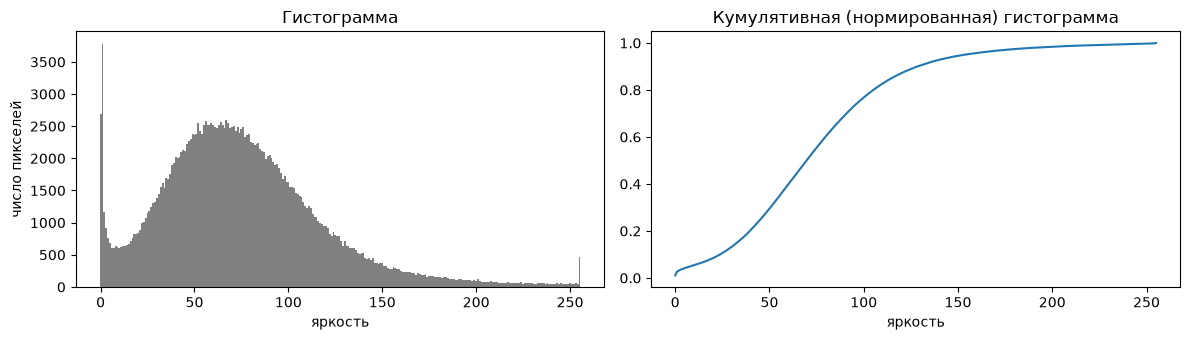

In [48]:
def calc_hist(img, bins=256):
    """Гистограмма 8-битного одноканального изображения: hist[i] = число пикселей со значением i."""
    return np.bincount(img.ravel(), minlength=bins)

hist = calc_hist(sar)
hist_cv = cv2.calcHist([sar], [0], None, [256], (0, 256)).ravel()
print("совпадает с cv2.calcHist:", np.array_equal(hist, hist_cv.astype(int)))
print("сумма гистограммы =", hist.sum(), "= h*w =", sar.shape[0] * sar.shape[1])
print("самое частое значение яркости:", hist.argmax(), f"({hist.max()} пикс.)")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(np.arange(256), hist, width=1.0, color='gray')
ax[0].set_title('Гистограмма')
ax[0].set_xlabel('яркость')
ax[0].set_ylabel('число пикселей')
ax[1].plot(hist.cumsum() / hist.sum())
ax[1].set_title('Кумулятивная (нормированная) гистограмма')
ax[1].set_xlabel('яркость')
plt.tight_layout()
plt.show()

## 3. Гамма-коррекция
$$R_{corrected}=\left(\frac{R_{uncorrected}}{R_{max}}\right)^{\gamma}\cdot R_{max},\quad R_{max}=255$$
* $\gamma<1$ — изображение светлее (тёмные области растягиваются),
* $\gamma>1$ — изображение темнее.

Реализовано через таблицу соответствия (LUT) на 256 значений.

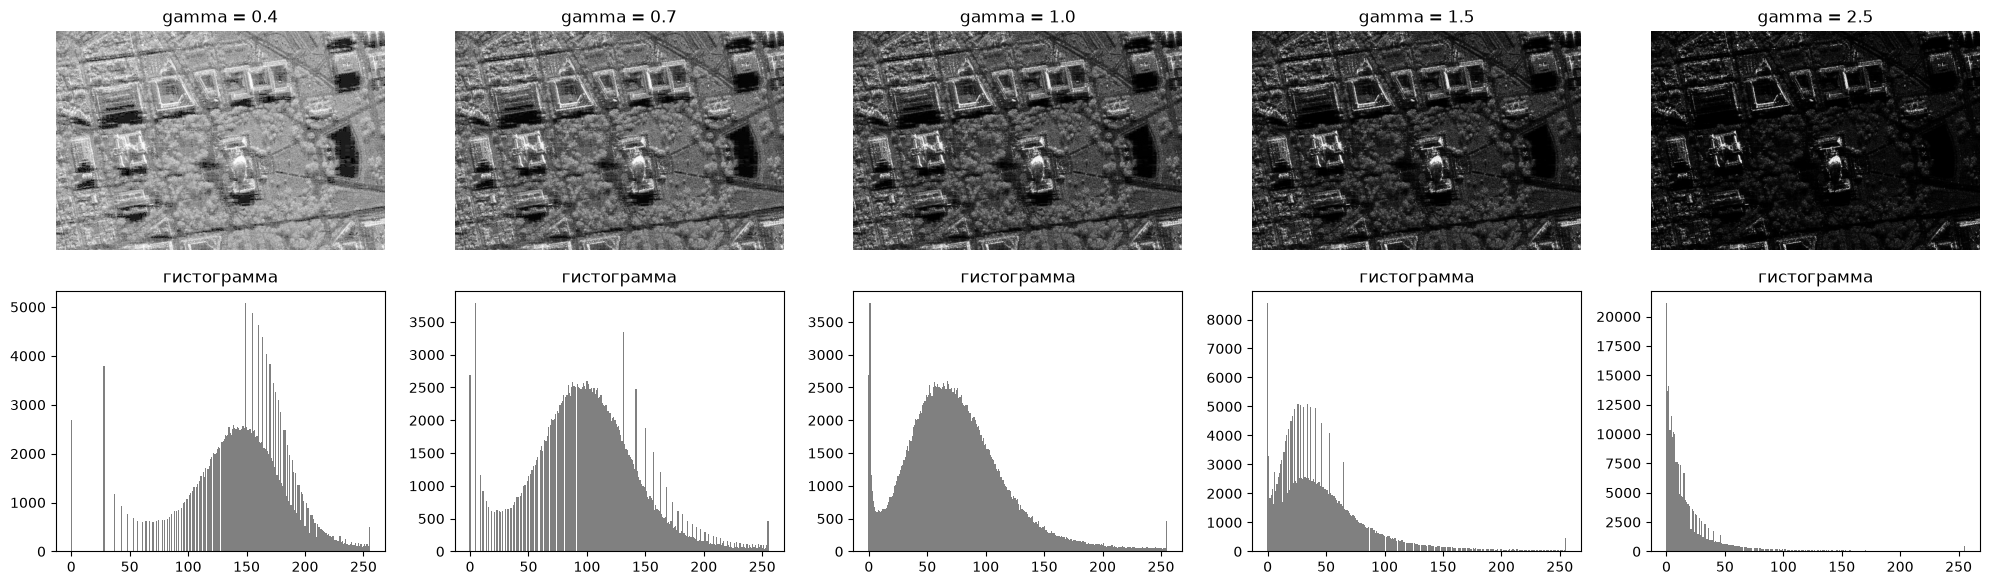

gamma = 0.4   mean =  148.06   std =  42.14
gamma = 0.7   mean =  103.87   std =  44.91
gamma = 1.0   mean =   74.94   std =  43.66
gamma = 1.5   mean =   45.69   std =  39.24
gamma = 2.5   mean =   20.01   std =  31.17


In [49]:
def gamma_correction(img, gamma, r_max=255):
    """Гамма-коррекция 8-битного изображения через LUT."""
    lut = (np.arange(256) / r_max) ** gamma * r_max
    lut = np.clip(np.round(lut), 0, 255).astype(np.uint8)
    return lut[img]

gammas = [0.4, 0.7, 1.0, 1.5, 2.5]
gamma_imgs = {g: gamma_correction(sar, g) for g in gammas}

fig, ax = plt.subplots(2, len(gammas), figsize=(4 * len(gammas), 6))
for k, g in enumerate(gammas):
    im = gamma_imgs[g]
    ax[0, k].imshow(im, cmap='gray', vmin=0, vmax=255)
    ax[0, k].set_title(f'gamma = {g}')
    ax[0, k].axis('off')
    ax[1, k].bar(np.arange(256), calc_hist(im), width=1.0, color='gray')
    ax[1, k].set_title('гистограмма')
plt.tight_layout()
plt.show()

for g in gammas:
    im = gamma_imgs[g]
    print(f"gamma = {g:<4}  mean = {im.mean():7.2f}   std = {im.std():6.2f}")

## 4. Сравнение исходного и скорректированного изображений: MSE, SSIM
MSE — чем меньше, тем ближе изображения (0 — идентичны). SSIM — чем ближе к 1, тем более похожа структура. Для контроля значение γ = 1 (тождественное преобразование) должно дать MSE = 0 и SSIM = 1.

In [50]:
import pandas as pd

def mse_own(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

rows = []
for g in gammas:
    im = gamma_imgs[g]
    mse = mean_squared_error(sar, im)
    ssim = structural_similarity(sar, im, data_range=255)
    assert np.isclose(mse, mse_own(sar, im))   # собственная реализация MSE совпадает с skimage
    rows.append({'gamma': g, 'MSE': round(mse, 2), 'SSIM': round(ssim, 4)})

df_gamma = pd.DataFrame(rows).set_index('gamma')
print(df_gamma)

           MSE    SSIM
gamma                 
0.4    5596.58  0.7103
0.7     886.23  0.9104
1.0       0.00  1.0000
1.5     945.28  0.8137
2.5    3503.88  0.3367


## 5. Линейная коррекция гистограммы (автоконтраст) и эквализация
Согласно `Notes.docx`, эквализация гистограммы (`eq_gray`) и коррекция гистограммы реализуются самостоятельно.

### 5.1 Эквализация гистограммы (собственная реализация)
Кумулятивная функция распределения нормируется так, чтобы максимум стал равен 255: $equalized(x,y)=H'(src(x,y))$. Нормировка выполнена по той же формуле, что и в `cv2.equalizeHist` (вычитается значение CDF в первой занятой ячейке), поэтому результат можно сверить с OpenCV.

макс. отличие от cv2.equalizeHist: 0
исходное:  mean = 74.94, std = 43.66
eq_gray:   mean = 127.03, std = 74.27


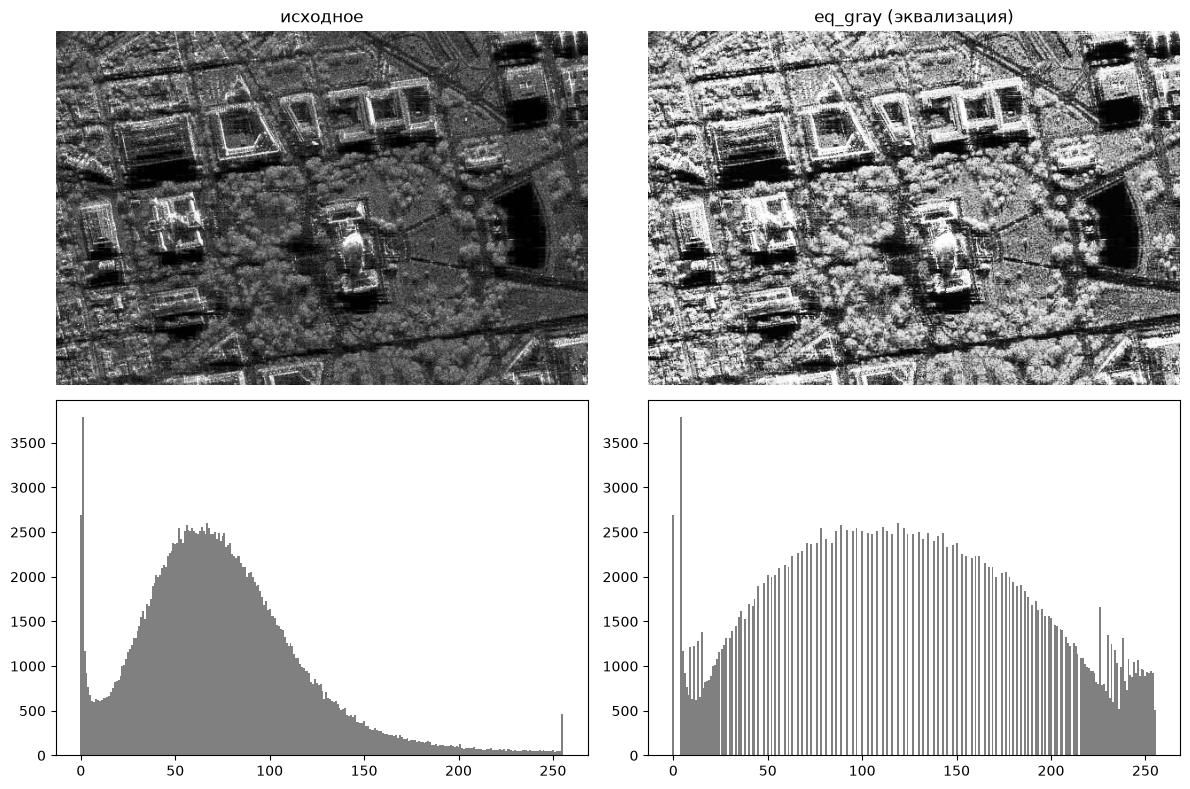

In [51]:
def equalize_hist(img):
    """Эквализация гистограммы 8-битного изображения (собственная реализация)."""
    hist = calc_hist(img)
    cdf = hist.cumsum()                      # H'(i) = sum_{j<=i} H(j)
    cdf_min = cdf[hist > 0][0]               # CDF в первой занятой ячейке
    total = img.size
    if cdf_min == total:                     # изображение одноцветное
        return img.copy()
    lut = np.round((cdf - cdf_min) / (total - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[img]

eq_gray = equalize_hist(sar)                 # <- то самое eq_gray из задания
eq_cv = cv2.equalizeHist(sar)
print("макс. отличие от cv2.equalizeHist:", np.abs(eq_gray.astype(int) - eq_cv.astype(int)).max())
print(f"исходное:  mean = {sar.mean():.2f}, std = {sar.std():.2f}")
print(f"eq_gray:   mean = {eq_gray.mean():.2f}, std = {eq_gray.std():.2f}")

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].imshow(sar, cmap='gray', vmin=0, vmax=255);     ax[0, 0].set_title('исходное');       ax[0, 0].axis('off')
ax[0, 1].imshow(eq_gray, cmap='gray', vmin=0, vmax=255); ax[0, 1].set_title('eq_gray (эквализация)'); ax[0, 1].axis('off')
ax[1, 0].bar(np.arange(256), calc_hist(sar), width=1.0, color='gray')
ax[1, 1].bar(np.arange(256), calc_hist(eq_gray), width=1.0, color='gray')
plt.tight_layout()
plt.show()

### 5.2 Линейная коррекция гистограммы (линейное растяжение, автоконтраст) — собственная реализация
Формула из лекции: пиксели линейно переводятся из диапазона $[I_{min}, I_{max}]$ изображения в целевой диапазон $[MIN, MAX]=[0, 255]$:
$$Stretch(I)=\frac{I-I_{min}}{I_{max}-I_{min}}\cdot(MAX-MIN)+MIN$$
У этого снимка $I_{min}=0$ и $I_{max}=255$, поэтому растяжение «в лоб» ничего не меняет (проверка ниже). Поэтому в качестве $I_{min}$ и $I_{max}$ берутся процентили яркости (автоконтраст с отсечением редких выбросов по краям гистограммы): значения ниже $I_{min}$ становятся 0, выше $I_{max}$ — 255.

I_min = 0, I_max = 255 -> результат совпадает с исходным изображением: True

вариант             I_min  I_max    mean     std  насыщ.,%       MSE    SSIM
min-max (0-100%)      0.0  255.0   74.94   43.66       1.3      0.00  1.0000
1-99%                 0.0  219.0   87.02   49.97       2.1    191.65  0.9783
2-98%                 1.0  191.0   98.43   55.90       4.7    732.21  0.9266
5-95%                 9.0  154.0  113.34   67.18      10.2   2169.90  0.8060
eq_gray (для сравн.)                127.03   74.27       1.3   4021.80  0.6991


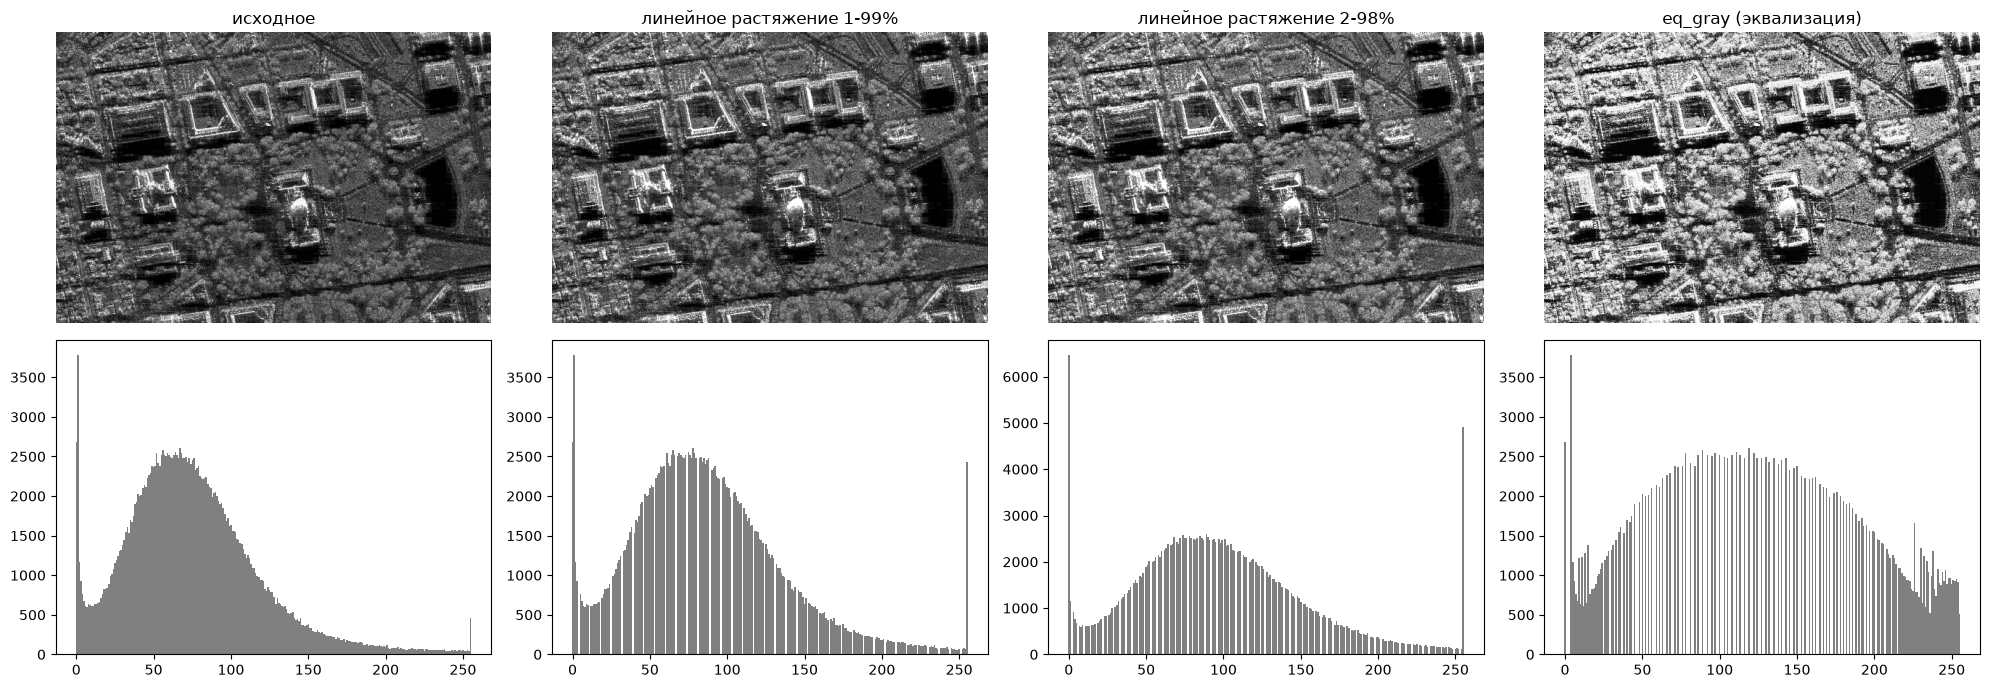

In [52]:
def linear_stretch(img, low_pct=0, high_pct=100, new_min=0, new_max=255):
    """Линейное растяжение гистограммы (собственная реализация).
    I_min и I_max - процентили яркости low_pct и high_pct (0 и 100 дают обычные min и max)."""
    i = img.astype(np.float64)
    i_min, i_max = np.percentile(i, [low_pct, high_pct])
    out = (i - i_min) / (i_max - i_min) * (new_max - new_min) + new_min
    return np.clip(np.round(out), new_min, new_max).astype(np.uint8)

# 1) растяжение по настоящим min и max
plain = linear_stretch(sar)
print(f"I_min = {sar.min()}, I_max = {sar.max()} -> результат совпадает с исходным изображением: {np.array_equal(plain, sar)}")
print()

# 2) растяжение с отсечением процентилей
variants = {'min-max (0-100%)': (0, 100), '1-99%': (1, 99), '2-98%': (2, 98), '5-95%': (5, 95)}
stretched = {}
print(f"{'вариант':18s}{'I_min':>7s}{'I_max':>7s}{'mean':>8s}{'std':>8s}{'насыщ.,%':>10s}{'MSE':>10s}{'SSIM':>8s}")
for name, (lo, hi) in variants.items():
    out = linear_stretch(sar, lo, hi)
    stretched[name] = out
    i_min, i_max = np.percentile(sar, [lo, hi])
    sat = 100 * ((out == 0) | (out == 255)).mean()
    print(f"{name:18s}{i_min:7.1f}{i_max:7.1f}{out.mean():8.2f}{out.std():8.2f}{sat:10.1f}"
          f"{mean_squared_error(sar, out):10.2f}{structural_similarity(sar, out, data_range=255):8.4f}")
sat_eq = 100 * ((eq_gray == 0) | (eq_gray == 255)).mean()
print(f"{'eq_gray (для сравн.)':18s}{'':14s}{eq_gray.mean():8.2f}{eq_gray.std():8.2f}{sat_eq:10.1f}"
      f"{mean_squared_error(sar, eq_gray):10.2f}{structural_similarity(sar, eq_gray, data_range=255):8.4f}")

sar_lin = stretched['2-98%']          # основной результат: растяжение по 2-му и 98-му процентилям

fig, ax = plt.subplots(2, 4, figsize=(20, 7))
for k, (im, title) in enumerate([(sar, 'исходное'), (stretched['1-99%'], 'линейное растяжение 1-99%'),
                                 (sar_lin, 'линейное растяжение 2-98%'), (eq_gray, 'eq_gray (эквализация)')]):
    ax[0, k].imshow(im, cmap='gray', vmin=0, vmax=255)
    ax[0, k].set_title(title)
    ax[0, k].axis('off')
    ax[1, k].bar(np.arange(256), calc_hist(im), width=1.0, color='gray')
plt.tight_layout()
plt.show()

## 6. Пороговая фильтрация с разными параметрами
Реализованы все пять типов из лекции (Binary, Binary Inv, Trunc, ToZero, ToZero Inv), результат сверяется с `cv2.threshold`. Пороги: 50, 100, 150, 200; `maxval` = 255.

In [53]:
def threshold(img, thresh, maxval=255, kind='binary'):
    mask = img > thresh
    if kind == 'binary':
        return np.where(mask, maxval, 0).astype(np.uint8)
    if kind == 'binary_inv':
        return np.where(mask, 0, maxval).astype(np.uint8)
    if kind == 'trunc':
        return np.where(mask, thresh, img).astype(np.uint8)
    if kind == 'tozero':
        return np.where(mask, img, 0).astype(np.uint8)
    if kind == 'tozero_inv':
        return np.where(mask, 0, img).astype(np.uint8)
    raise ValueError(kind)

cv_types = {'binary': cv2.THRESH_BINARY, 'binary_inv': cv2.THRESH_BINARY_INV, 'trunc': cv2.THRESH_TRUNC,
            'tozero': cv2.THRESH_TOZERO, 'tozero_inv': cv2.THRESH_TOZERO_INV}
thresholds = [50, 100, 150, 200]

# проверка на совпадение с OpenCV
ok = all(np.array_equal(threshold(sar, t, 255, k), cv2.threshold(sar, t, 255, c)[1])
         for k, c in cv_types.items() for t in thresholds)
print("все варианты совпадают с cv2.threshold:", ok)

все варианты совпадают с cv2.threshold: True


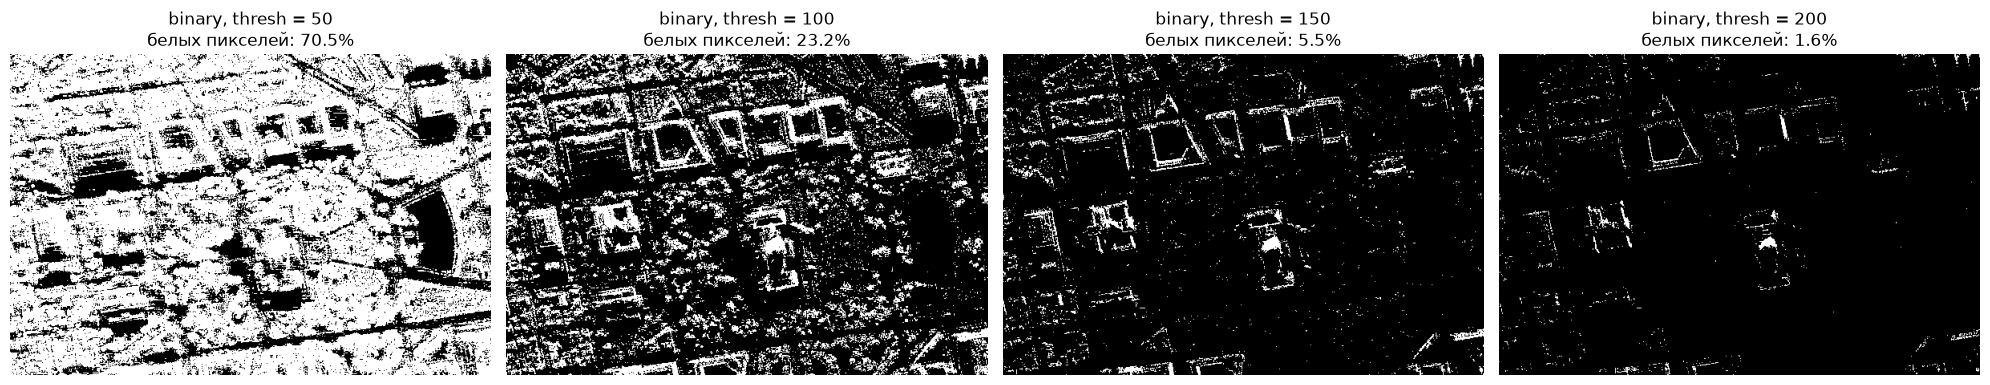

thresh =  50: доля пикселей > порога =  70.5%
thresh = 100: доля пикселей > порога =  23.2%
thresh = 150: доля пикселей > порога =   5.5%
thresh = 200: доля пикселей > порога =   1.6%


In [54]:
# 6.1 Binary при разных порогах
fig, ax = plt.subplots(1, len(thresholds), figsize=(5 * len(thresholds), 4))
for a, t in zip(ax, thresholds):
    res = threshold(sar, t, 255, 'binary')
    a.imshow(res, cmap='gray', vmin=0, vmax=255)
    a.set_title(f'binary, thresh = {t}\nбелых пикселей: {100 * (res == 255).mean():.1f}%')
    a.axis('off')
plt.tight_layout()
plt.show()

for t in thresholds:
    print(f"thresh = {t:3d}: доля пикселей > порога = {100 * (sar > t).mean():5.1f}%")

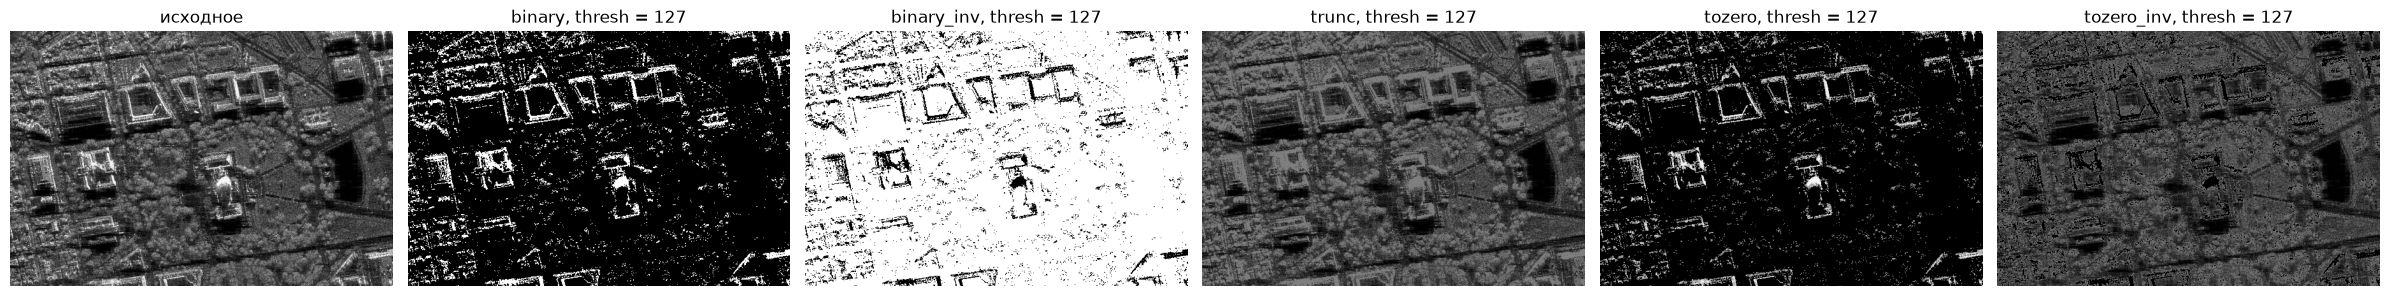

In [55]:
# 6.2 Все пять типов при пороге 127 (и maxval = 255)
fig, ax = plt.subplots(1, 6, figsize=(24, 3.6))
ax[0].imshow(sar, cmap='gray', vmin=0, vmax=255); ax[0].set_title('исходное'); ax[0].axis('off')
for a, k in zip(ax[1:], cv_types):
    a.imshow(threshold(sar, 127, 255, k), cmap='gray', vmin=0, vmax=255)
    a.set_title(f'{k}, thresh = 127')
    a.axis('off')
plt.tight_layout()
plt.show()

порог Оцу: 85.0


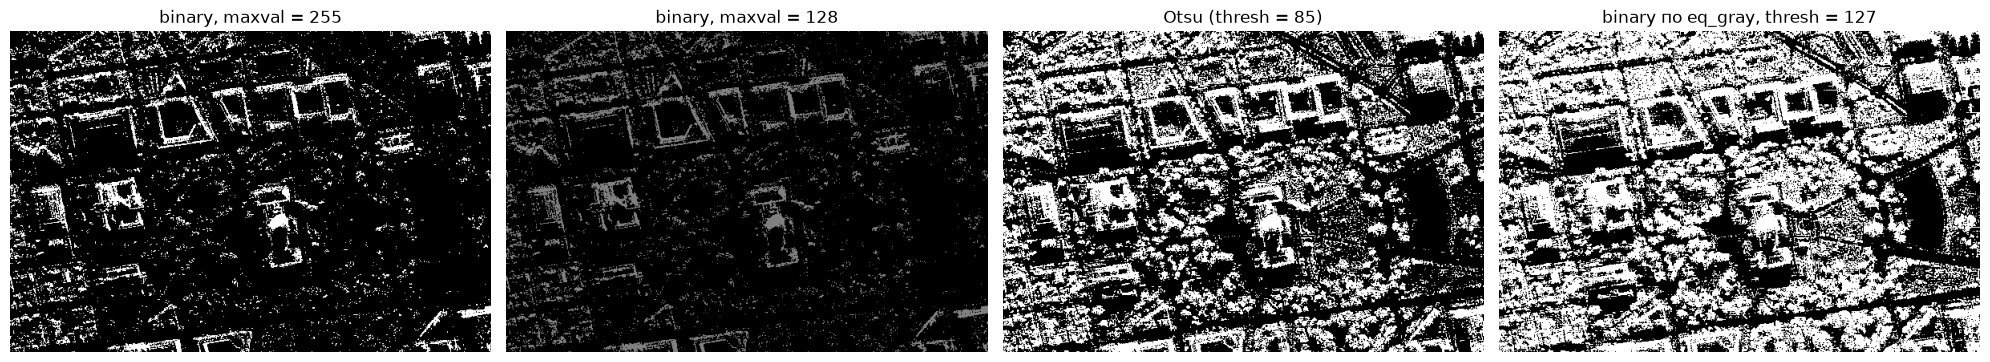

In [56]:
# 6.3 Влияние maxval (binary, thresh = 127) и порог по Оцу как «автоматический» параметр
otsu_t, otsu_img = cv2.threshold(sar, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("порог Оцу:", otsu_t)

variants = [('binary, maxval = 255', threshold(sar, 127, 255, 'binary')),
            ('binary, maxval = 128', threshold(sar, 127, 128, 'binary')),
            (f'Otsu (thresh = {otsu_t:.0f})', otsu_img),
            ('binary по eq_gray, thresh = 127', threshold(eq_gray, 127, 255, 'binary'))]
fig, ax = plt.subplots(1, len(variants), figsize=(5 * len(variants), 4))
for a, (title, im) in zip(ax, variants):
    a.imshow(im, cmap='gray', vmin=0, vmax=255)
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

## Выводы
* **Гамма-коррекция:** γ < 1 осветляет изображение (среднее растёт), γ > 1 затемняет; при γ = 1 MSE = 0 и SSIM = 1. Чем сильнее γ отличается от 1, тем больше MSE и ниже SSIM относительно исходного (см. таблицу в п. 4).
* **Эквализация:** собственная реализация полностью совпадает с `cv2.equalizeHist` (максимальное отличие 0); гистограмма растягивается на весь диапазон 0–255, СКО растёт с ≈44 до ≈74.
* **Линейная коррекция гистограммы:** у снимка $I_{min}=0$ и $I_{max}=255$, поэтому растяжение по формуле из лекции «в лоб» ничего не меняет. С отсечением процентилей (автоконтраст) контраст растёт: чем уже интервал $[I_{min}, I_{max}]$, тем больше СКО (44 → 50 → 56 → 67 для 1–99%, 2–98%, 5–95%), но и тем больше насыщенных пикселей (0 и 255): 1.3% → 2.1% → 4.7% → 10.2%. Преобразование линейное, поэтому форма гистограммы сохраняется (в отличие от эквализации), а лишние значения обрезаются по краям.
* **Пороги:** от порога сильно зависит доля белых пикселей (70% при 50 → 1.6% при 200); на этом снимке низкий порог оставляет большую часть пикселей, высокий — только самые яркие. Собственные реализации всех пяти типов совпадают с `cv2.threshold`.